<a href="https://colab.research.google.com/github/Ssahu620/SS-ML-AI-Module-11-Assignment/blob/main/v7_ss_prompt_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.

**ss - Main task is to find dimensions (columns of vehicles spreadsheet) that impact the price most.

To get the most important dimensions, steps will be as follows:


1.   Import all libraries.
2.   Load data, clean data, drop unnecessary columns.
3.   Replace NA values appropriately.
4.   Use one-hot algorithm to convert values to numerical values.
5.   Run PCA model to figure out the most important dimensions.
6.   Use multiple regression to get the coeffecients of features/dimensions.
7.   Use error metrics - find MSE
8.   Run a new model with polynomial features.
9.   Use Validations - CV- Gridsearch.
10.  If polynomial model is not appropriate then run simple multiple regression with degree = 1.
10.  Keep plotting plots to visually show results.
11.  Summarize final results
**

**
**



ss - Step 1 - Import all required libraries.

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import GridSearchCV

In [49]:
vehicles = pd.read_csv('data/vehicles.csv')
vehicles.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


ss - Find out which columns have null values and how many

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [50]:
vehicles.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

ss - find out which columns have null values and what is their proportion to the total number of rows.

In [51]:
null_counts = vehicles.isnull().sum()
null_cols = null_counts[null_counts >0]
null_cols

,0
year,1205
manufacturer,17646
model,5277
condition,174104
cylinders,177678
fuel,3013
odometer,4400
title_status,8242
transmission,2556
VIN,161042


In [52]:
proportion = null_counts / vehicles.shape[0]
proportion

,0
id,0.000000
region,0.000000
price,0.000000
year,0.002823
manufacturer,0.041337
model,0.012362
condition,0.407852
cylinders,0.416225
fuel,0.007058
odometer,0.010307


ss - find out how many unique values are there in each column

In [53]:
unique_values = vehicles.nunique()
unique_values

,0
id,426880
region,404
price,15655
year,114
manufacturer,42
model,29649
condition,6
cylinders,8
fuel,5
odometer,104870


ss - Merge null_cols, proportion, and unique_vaues in to one dataframe and show it.

In [54]:
null_counts = vehicles.isnull().sum()
null_cols = null_counts[null_counts >0]
proportion = null_counts / vehicles.shape[0]
unique_values = vehicles.nunique()
null_cols = pd.DataFrame({'Column': null_cols.index, 'Null_Count': null_cols.values})
proportions = pd.DataFrame({'Column': proportion.index, 'Proportion': proportion.values})
unique_values_df = pd.DataFrame({'Column': unique_values.index, 'Unique_Values': unique_values.values})


# Merge the DataFrames
merged_df = pd.merge(null_cols, proportions, on='Column', how='left')
merged_df = pd.merge(merged_df, unique_values_df, on='Column', how='left')

merged_df

,Column,Null_Count,Proportion,Unique_Values
0,year,1205,0.002823,114
1,manufacturer,17646,0.041337,42
2,model,5277,0.012362,29649
3,condition,174104,0.407852,6
4,cylinders,177678,0.416225,8
5,fuel,3013,0.007058,5
6,odometer,4400,0.010307,104870
7,title_status,8242,0.019308,6
8,transmission,2556,0.005988,3
9,VIN,161042,0.377254,118246


In [55]:
fuel_counts = vehicles['fuel'].value_counts()
condition_counts = vehicles['condition'].value_counts()
cylinders_counts = vehicles['cylinders'].value_counts()
drive_counts = vehicles['drive'].value_counts()
size_counts = vehicles['size'].value_counts()
type_counts = vehicles['type'].value_counts()
print(fuel_counts,  fuel_counts/vehicles.shape[0], "\n")
print(condition_counts, condition_counts/vehicles.shape[0], "\n")
print(cylinders_counts, cylinders_counts/vehicles.shape[0], "\n")
print(drive_counts, drive_counts/vehicles.shape[0], "\n")
print(size_counts, size_counts/vehicles.shape[0], "\n")
print(type_counts, type_counts/vehicles.shape[0], "\n")



fuel
gas         356209
other        30728
diesel       30062
hybrid        5170
electric      1698
Name: count, dtype: int64 fuel
gas         0.834448
other       0.071983
diesel      0.070423
hybrid      0.012111
electric    0.003978
Name: count, dtype: float64 

condition
good         121456
excellent    101467
like new      21178
fair           6769
new            1305
salvage         601
Name: count, dtype: int64 condition
good         0.284520
excellent    0.237694
like new     0.049611
fair         0.015857
new          0.003057
salvage      0.001408
Name: count, dtype: float64 

cylinders
6 cylinders     94169
4 cylinders     77642
8 cylinders     72062
5 cylinders      1712
10 cylinders     1455
other            1298
3 cylinders       655
12 cylinders      209
Name: count, dtype: int64 cylinders
6 cylinders     0.220598
4 cylinders     0.181882
8 cylinders     0.168811
5 cylinders     0.004010
10 cylinders    0.003408
other           0.003041
3 cylinders     0.001534
12 cylind

ss - Dropping columns where null values are 35% or more

In [56]:
vehicles.drop(['paint_color', 'size', 'drive', 'VIN', 'cylinders', 'condition'], axis = 1, inplace = True)


null_counts = vehicles.isnull().sum()
null_cols = null_counts[null_counts >0]
proportion = null_counts / vehicles.shape[0]
unique_values = vehicles.nunique()
null_cols = pd.DataFrame({'Column': null_cols.index, 'Null_Count': null_cols.values})
proportions = pd.DataFrame({'Column': proportion.index, 'Proportion': proportion.values})
unique_values_df = pd.DataFrame({'Column': unique_values.index, 'Unique_Values': unique_values.values})


# Merge the DataFrames
merged_df = pd.merge(null_cols, proportions, on='Column', how='left')
merged_df = pd.merge(merged_df, unique_values_df, on='Column', how='left')

merged_df




,Column,Null_Count,Proportion,Unique_Values
0,year,1205,0.002823,114
1,manufacturer,17646,0.041337,42
2,model,5277,0.012362,29649
3,fuel,3013,0.007058,5
4,odometer,4400,0.010307,104870
5,title_status,8242,0.019308,6
6,transmission,2556,0.005988,3
7,type,92858,0.217527,13


ss - Dropping column "type" because "model" will show the same feature as "type".

In [57]:
vehicles.drop(['type'], axis = 1, inplace = True)

ss - find out frequncy of values for manufacturer.

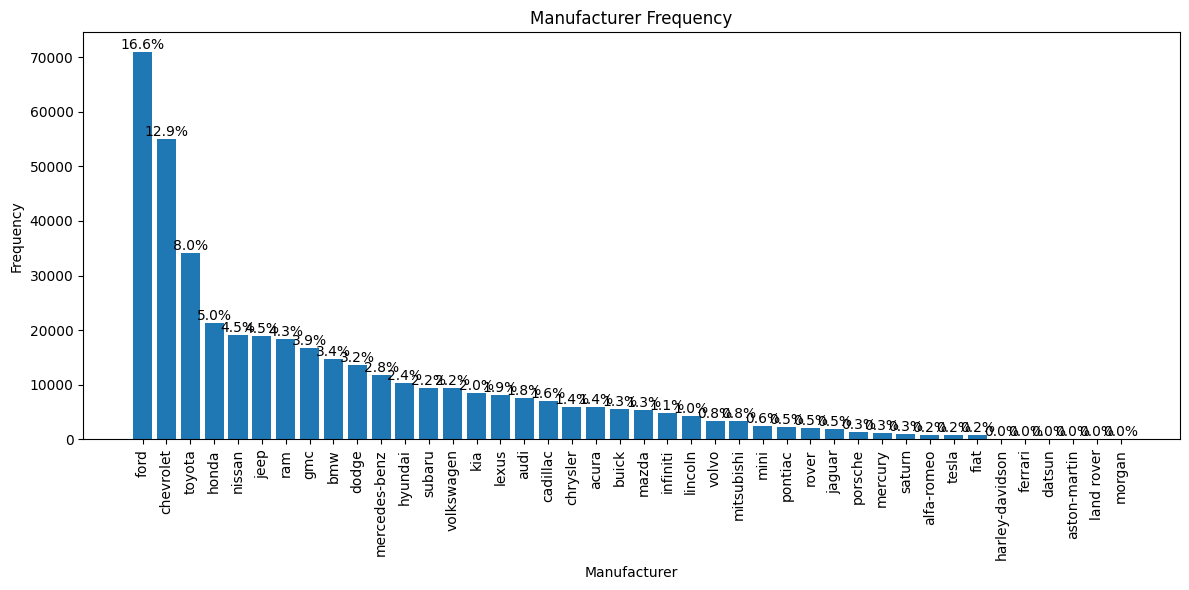

In [58]:
manufact_count = vehicles['manufacturer'].value_counts()

plt.figure(figsize=(12, 6))
plt.bar(manufact_count.index, manufact_count.values)
plt.xlabel("Manufacturer")
plt.ylabel("Frequency")
plt.title("Manufacturer Frequency")
plt.xticks(rotation=90)

# Add percentage labels above each bar
for i, count in enumerate(manufact_count.values):
    percentage = (count / vehicles.shape[0]) * 100
    plt.text(i, count, f'{percentage:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()
#manufact_count.hist()
#print(manufact_count, "\n", manufact_count/vehicles.shape[0], "\n")

ss - Replace null value in manufacturer with equal numbers as ford, cheverolte, and toyota

In [59]:
# prompt: Replace null value in manufacturer with equal numbers as ford, cheverolte, and toyota

# Calculate the number of null values in the 'manufacturer' column
null_manufacturer_count = vehicles['manufacturer'].isnull().sum()

# Calculate the number of occurrences for 'ford', 'chevrolet', and 'toyota'
ford_count = vehicles['manufacturer'].value_counts().get('ford', 0)
chevrolet_count = vehicles['manufacturer'].value_counts().get('chevrolet', 0)
toyota_count = vehicles['manufacturer'].value_counts().get('toyota', 0)

# Distribute the null values proportionally among the three manufacturers
ford_fill = int(null_manufacturer_count * (ford_count / (ford_count + chevrolet_count + toyota_count)))
chevrolet_fill = int(null_manufacturer_count * (chevrolet_count / (ford_count + chevrolet_count + toyota_count)))
toyota_fill = null_manufacturer_count - ford_fill - chevrolet_fill  # Remaining nulls go to Toyota

# Create lists for replacement values
manufacturer_replacements = ['ford'] * ford_fill + ['chevrolet'] * chevrolet_fill + ['toyota'] * toyota_fill
#Shuffle the replacement values to avoid any bias in order
import random
random.shuffle(manufacturer_replacements)

# Fill null values in 'manufacturer' column
vehicles.loc[vehicles['manufacturer'].isnull(), 'manufacturer'] = manufacturer_replacements


In [60]:
null_counts = vehicles.isnull().sum()
null_cols = null_counts[null_counts >0]
null_cols

,0
year,1205
model,5277
fuel,3013
odometer,4400
title_status,8242
transmission,2556


ss -Dropping all remaining null values from vehicles as they are less than 2% of each category.

In [61]:
vehicles.dropna(axis = 0, inplace = True)
null_counts = vehicles.isnull().sum()
null_cols = null_counts[null_counts >0]
null_cols


,0


In [62]:
vehicles.info()

<class 'pandas.core.frame.DataFrame'>
Index: 405594 entries, 27 to 426879
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            405594 non-null  int64  
 1   region        405594 non-null  object 
 2   price         405594 non-null  int64  
 3   year          405594 non-null  float64
 4   manufacturer  405594 non-null  object 
 5   model         405594 non-null  object 
 6   fuel          405594 non-null  object 
 7   odometer      405594 non-null  float64
 8   title_status  405594 non-null  object 
 9   transmission  405594 non-null  object 
 10  state         405594 non-null  object 
dtypes: float64(2), int64(2), object(7)
memory usage: 37.1+ MB


In [63]:
vehicles.drop(['id'], axis = 1, inplace = True)
vehicles.reset_index(drop = True, inplace = True)

In [64]:
vehicles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405594 entries, 0 to 405593
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   region        405594 non-null  object 
 1   price         405594 non-null  int64  
 2   year          405594 non-null  float64
 3   manufacturer  405594 non-null  object 
 4   model         405594 non-null  object 
 5   fuel          405594 non-null  object 
 6   odometer      405594 non-null  float64
 7   title_status  405594 non-null  object 
 8   transmission  405594 non-null  object 
 9   state         405594 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 30.9+ MB


In [65]:
vehicles.head()

,region,price,year,manufacturer,model,fuel,odometer,title_status,transmission,state
0,auburn,33590,2014.0,gmc,sierra 1500 crew cab slt,gas,57923.0,clean,other,al
1,auburn,22590,2010.0,chevrolet,silverado 1500,gas,71229.0,clean,other,al
2,auburn,39590,2020.0,chevrolet,silverado 1500 crew,gas,19160.0,clean,other,al
3,auburn,30990,2017.0,toyota,tundra double cab sr,gas,41124.0,clean,other,al
4,auburn,15000,2013.0,ford,f-150 xlt,gas,128000.0,clean,automatic,al


In [66]:
unique_values = vehicles.nunique()
unique_values_df = pd.DataFrame({'Column': unique_values.index, 'Unique_Values': unique_values.values})
unique_values_df


,Column,Unique_Values
0,region,404
1,price,14856
2,year,113
3,manufacturer,41
4,model,27496
5,fuel,5
6,odometer,101872
7,title_status,6
8,transmission,3
9,state,51


ss - I don't beleive state or region will have any bearing on price. Dropping state and region.

In [67]:
vehicles.drop(['state', 'region'], axis = 1, inplace = True)
unique_values = vehicles.nunique()
unique_values_df = pd.DataFrame({'Column': unique_values.index, 'Unique_Values': unique_values.values})
unique_values_df

,Column,Unique_Values
0,price,14856
1,year,113
2,manufacturer,41
3,model,27496
4,fuel,5
5,odometer,101872
6,title_status,6
7,transmission,3


In [68]:
vehicles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 405594 entries, 0 to 405593
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         405594 non-null  int64  
 1   year          405594 non-null  float64
 2   manufacturer  405594 non-null  object 
 3   model         405594 non-null  object 
 4   fuel          405594 non-null  object 
 5   odometer      405594 non-null  float64
 6   title_status  405594 non-null  object 
 7   transmission  405594 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 24.8+ MB


ss - Data is for 113 years. Due to major economic and social changes past years data may not be relevant. Only taking data from 2000 onwards.

In [69]:
vehicle_2000 = vehicles[vehicles['year']>=2000]
vehicles_2000 = vehicle_2000.reset_index(drop = True)
vehicle_2000.info()
print ("Number of rows", vehicles_2000.shape[0])

<class 'pandas.core.frame.DataFrame'>
Index: 382091 entries, 0 to 405593
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         382091 non-null  int64  
 1   year          382091 non-null  float64
 2   manufacturer  382091 non-null  object 
 3   model         382091 non-null  object 
 4   fuel          382091 non-null  object 
 5   odometer      382091 non-null  float64
 6   title_status  382091 non-null  object 
 7   transmission  382091 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 26.2+ MB
Number of rows 382091


### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.

In [70]:
vehicles_2000.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 382091 entries, 0 to 382090
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         382091 non-null  int64  
 1   year          382091 non-null  float64
 2   manufacturer  382091 non-null  object 
 3   model         382091 non-null  object 
 4   fuel          382091 non-null  object 
 5   odometer      382091 non-null  float64
 6   title_status  382091 non-null  object 
 7   transmission  382091 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 23.3+ MB


ss - There are too many values in models - dropping the column.

In [71]:
vehicles_2000.drop(['model'], axis = 1, inplace = True)
#vehicles.info()

In [72]:
vehicles_2000.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 382091 entries, 0 to 382090
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         382091 non-null  int64  
 1   year          382091 non-null  float64
 2   manufacturer  382091 non-null  object 
 3   fuel          382091 non-null  object 
 4   odometer      382091 non-null  float64
 5   title_status  382091 non-null  object 
 6   transmission  382091 non-null  object 
dtypes: float64(2), int64(1), object(4)
memory usage: 20.4+ MB


using lable encoding to convert fuel, title_status, transmission to integer         

In [73]:
# prompt: Use able encoding to convert fuel, title_status, transmission to integer in vehicles_2000

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
vehicles_2000['fuel'] = le.fit_transform(vehicles_2000['fuel'])
vehicles_2000['title_status'] = le.fit_transform(vehicles_2000['title_status'])
vehicles_2000['transmission'] = le.fit_transform(vehicles_2000['transmission'])


In [74]:
vehicles_2000.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 382091 entries, 0 to 382090
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         382091 non-null  int64  
 1   year          382091 non-null  float64
 2   manufacturer  382091 non-null  object 
 3   fuel          382091 non-null  int64  
 4   odometer      382091 non-null  float64
 5   title_status  382091 non-null  int64  
 6   transmission  382091 non-null  int64  
dtypes: float64(2), int64(4), object(1)
memory usage: 20.4+ MB


In [75]:
vehicles_2000.head()

,price,year,manufacturer,fuel,odometer,title_status,transmission
0,33590,2014.0,gmc,2,57923.0,0,2
1,22590,2010.0,chevrolet,2,71229.0,0,2
2,39590,2020.0,chevrolet,2,19160.0,0,2
3,30990,2017.0,toyota,2,41124.0,0,2
4,15000,2013.0,ford,2,128000.0,0,0


use one hot encoding to convert manufacturer to integer


In [76]:
# prompt: use one hot encoding to convert manufacturer to integer in vehicles_2000

# Use one-hot encoding to convert manufacturer to integer
vehicles_2000 = pd.get_dummies(vehicles_2000, columns=['manufacturer'], prefix='manufacturer')
vehicles_2000.info()
vehicles_2000.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 382091 entries, 0 to 382090
Data columns (total 46 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   price                         382091 non-null  int64  
 1   year                          382091 non-null  float64
 2   fuel                          382091 non-null  int64  
 3   odometer                      382091 non-null  float64
 4   title_status                  382091 non-null  int64  
 5   transmission                  382091 non-null  int64  
 6   manufacturer_acura            382091 non-null  bool   
 7   manufacturer_alfa-romeo       382091 non-null  bool   
 8   manufacturer_aston-martin     382091 non-null  bool   
 9   manufacturer_audi             382091 non-null  bool   
 10  manufacturer_bmw              382091 non-null  bool   
 11  manufacturer_buick            382091 non-null  bool   
 12  manufacturer_cadillac         382091 non-nul

,price,year,fuel,odometer,title_status,transmission,manufacturer_acura,manufacturer_alfa-romeo,manufacturer_aston-martin,manufacturer_audi,...,manufacturer_pontiac,manufacturer_porsche,manufacturer_ram,manufacturer_rover,manufacturer_saturn,manufacturer_subaru,manufacturer_tesla,manufacturer_toyota,manufacturer_volkswagen,manufacturer_volvo
0,33590,2014.0,2,57923.0,0,2,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,22590,2010.0,2,71229.0,0,2,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,39590,2020.0,2,19160.0,0,2,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,30990,2017.0,2,41124.0,0,2,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,15000,2013.0,2,128000.0,0,0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Show histograms for year, fuel, odometer, fuel transmission, and title_status

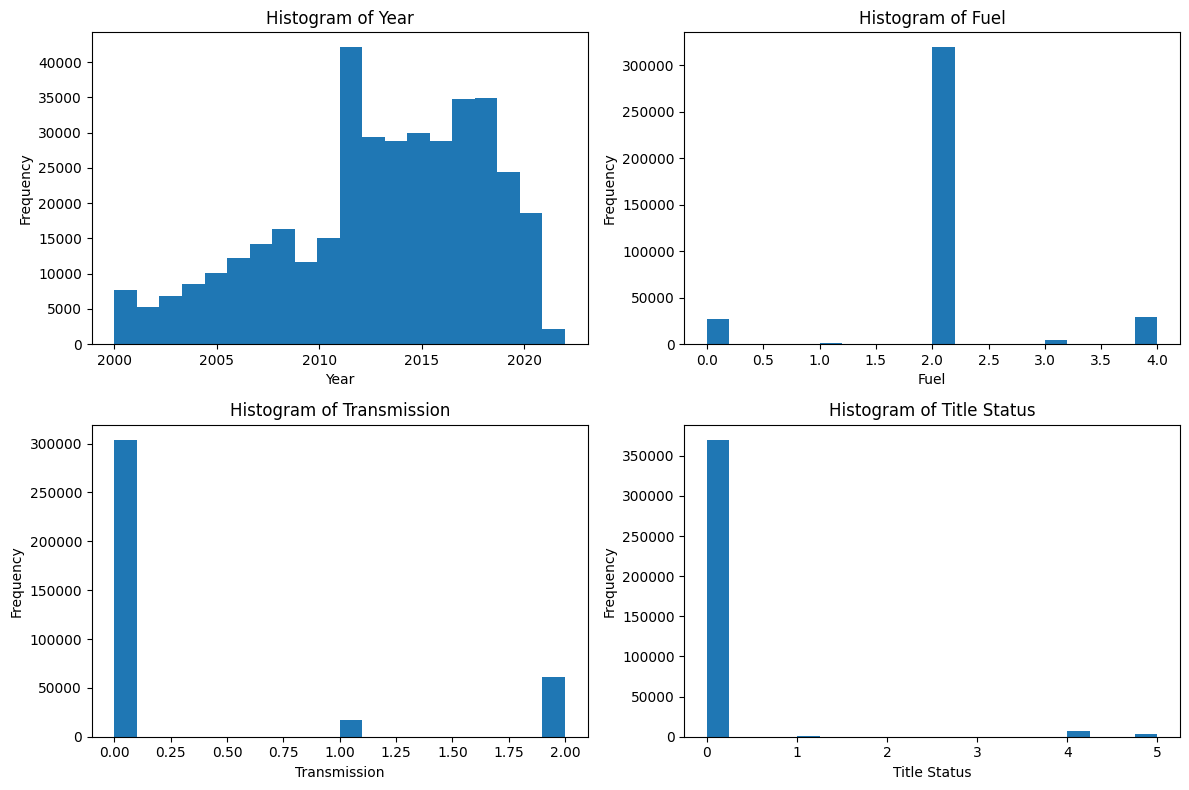

In [77]:
# prompt: Show histograms for year, fuel, transmission, and title_status in vehicles_2000

# Show histograms for year, fuel, transmission, and title_status
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.hist(vehicles_2000['year'], bins=20)
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.title('Histogram of Year')

plt.subplot(2, 2, 2)
plt.hist(vehicles_2000['fuel'], bins=20)
plt.xlabel('Fuel')
plt.ylabel('Frequency')
plt.title('Histogram of Fuel')

plt.subplot(2, 2, 3)
plt.hist(vehicles_2000['transmission'], bins=20)
plt.xlabel('Transmission')
plt.ylabel('Frequency')
plt.title('Histogram of Transmission')

plt.subplot(2, 2, 4)
plt.hist(vehicles_2000['title_status'], bins=20)
plt.xlabel('Title Status')
plt.ylabel('Frequency')
plt.title('Histogram of Title Status')

plt.tight_layout()
plt.show()


ss -plot year, transmission, title_status, odometer, fuel  against price in vehicles_2000 separately


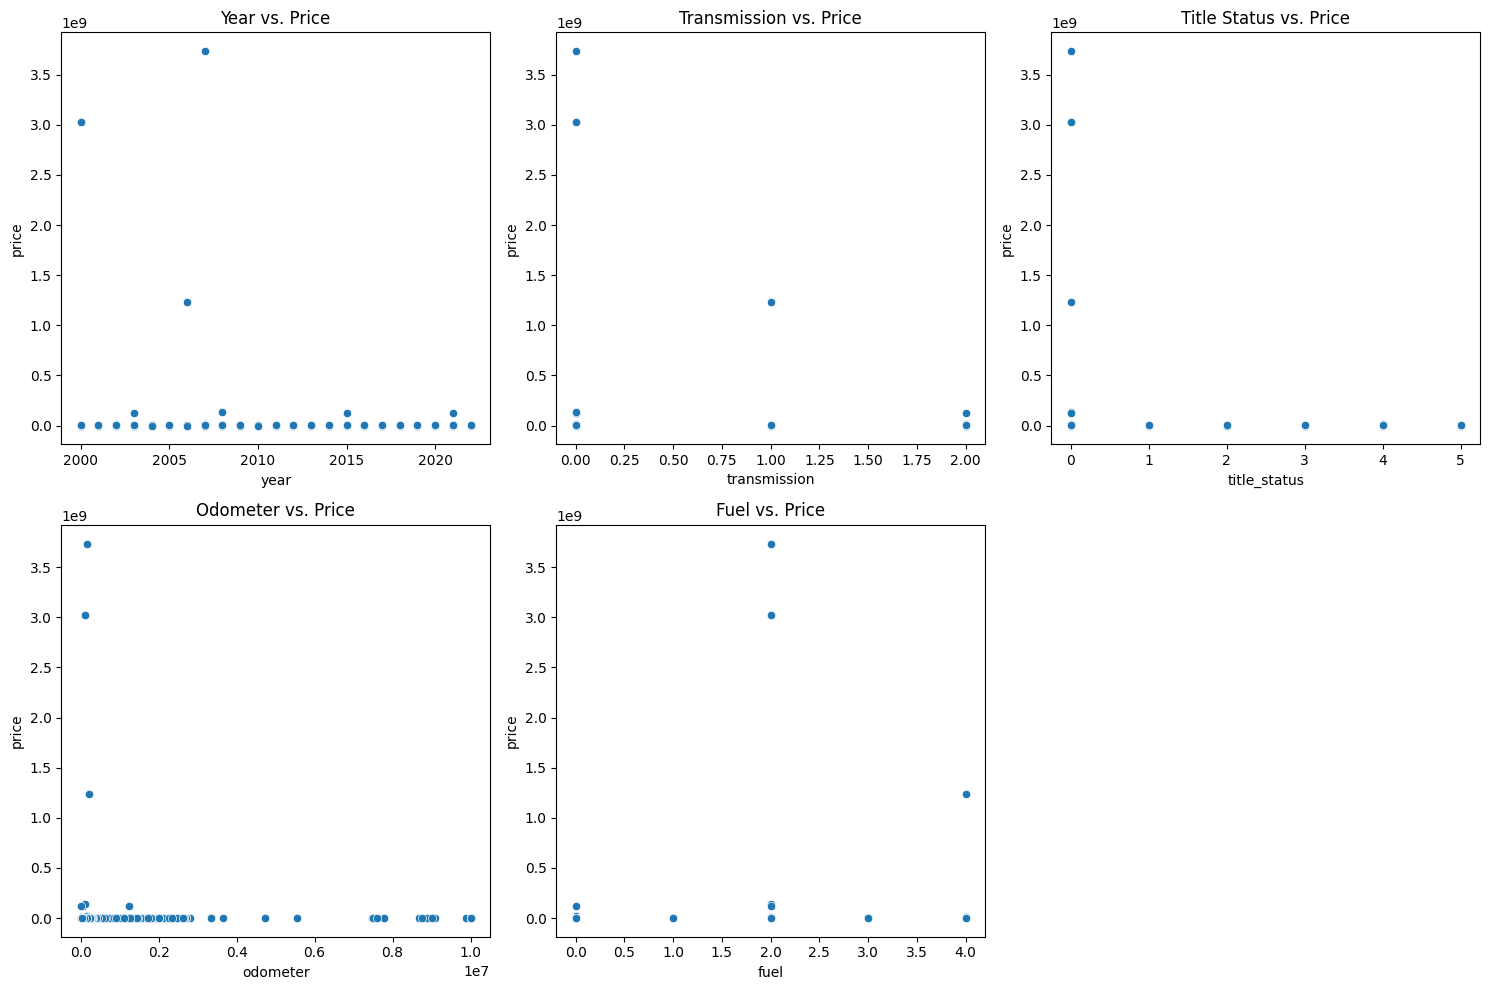

In [78]:
# prompt: plot year, transmission, title_status, odometer, fuel against price in vehicles_2000 using seaborn

# Plot year, transmission, title_status, odometer, fuel against price
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
sns.scatterplot(x='year', y='price', data=vehicles_2000)
plt.title('Year vs. Price')

plt.subplot(2, 3, 2)
sns.scatterplot(x='transmission', y='price', data=vehicles_2000)
plt.title('Transmission vs. Price')

plt.subplot(2, 3, 3)
sns.scatterplot(x='title_status', y='price', data=vehicles_2000)
plt.title('Title Status vs. Price')

plt.subplot(2, 3, 4)
sns.scatterplot(x='odometer', y='price', data=vehicles_2000)
plt.title('Odometer vs. Price')

plt.subplot(2, 3, 5)
sns.scatterplot(x='fuel', y='price', data=vehicles_2000)
plt.title('Fuel vs. Price')

plt.tight_layout()
plt.show()


create a multiple linear regression model using price as the target in vehicles_2000

In [79]:
# prompt: create a multiple linear regression model using price as the target in vehicles_2000

# Create a multiple linear regression model
X = vehicles_2000.drop('price', axis=1)
y = vehicles_2000['price']
model = LinearRegression()
model.fit(X, y)

# Print the coefficients and intercept
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)


Coefficients: [-1.11076082e+04  1.21840741e+04 -3.67795568e-02 -6.80784922e+03
  1.04903262e+04 -2.10278368e+04  1.58780287e+04 -1.79207601e+03
 -9.33005397e+03 -2.45100252e+04 -3.01122103e+04 -2.35211364e+04
 -2.41523572e+04 -4.70832637e+04 -2.43872793e+04  4.38361019e+04
 -1.70416721e+04 -2.21201998e+04 -1.54267291e+04 -7.84708626e+04
 -4.75007609e+04 -2.34503573e+04 -1.97560135e+04 -5.45904420e+03
 -2.03751337e+04 -1.45044433e+04 -5.47245386e+04 -3.85968880e+04
 -1.77957804e+04 -3.35800432e+04  5.52731917e+05 -1.14948252e+05
 -3.21144069e+04 -1.83039864e+04 -1.73256381e+04 -1.07572681e+05
 -3.08669971e+04  9.62651775e+03 -4.18789364e+03 -1.05110857e+05
 -3.21266533e+04  3.15039727e+04  7.80064857e+04 -2.36453652e+04
  3.69338411e+05]
Intercept: 22379032.063101117


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.


** ss -create a multiple linear regression model using price as the target in vehicles_2000**


In [80]:
X = vehicles_2000.drop('price', axis=1)
y = vehicles_2000['price']
model = LinearRegression()
model.fit(X, y)

# Print the coefficients and intercept
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [-1.11076082e+04  1.21840741e+04 -3.67795568e-02 -6.80784922e+03
  1.04903262e+04 -2.10278368e+04  1.58780287e+04 -1.79207601e+03
 -9.33005397e+03 -2.45100252e+04 -3.01122103e+04 -2.35211364e+04
 -2.41523572e+04 -4.70832637e+04 -2.43872793e+04  4.38361019e+04
 -1.70416721e+04 -2.21201998e+04 -1.54267291e+04 -7.84708626e+04
 -4.75007609e+04 -2.34503573e+04 -1.97560135e+04 -5.45904420e+03
 -2.03751337e+04 -1.45044433e+04 -5.47245386e+04 -3.85968880e+04
 -1.77957804e+04 -3.35800432e+04  5.52731917e+05 -1.14948252e+05
 -3.21144069e+04 -1.83039864e+04 -1.73256381e+04 -1.07572681e+05
 -3.08669971e+04  9.62651775e+03 -4.18789364e+03 -1.05110857e+05
 -3.21266533e+04  3.15039727e+04  7.80064857e+04 -2.36453652e+04
  3.69338411e+05]
Intercept: 22379032.063101117


ss -calculate mse for initial model

In [81]:
# prompt: calculate mse for initial model

# Make predictions on the training set
y_pred = model.predict(X)

# Calculate the Mean Squared Error (MSE)
mse = mean_squared_error(y, y_pred)
print(f"Mean Squared Error (MSE): {mse}")


Mean Squared Error (MSE): 88586144296563.25


ss - Normalize standard variables

In [82]:
# prompt: Normalize X and run multiple linear regression, print  coefficients with column names and print mean squared error

# Normalize the features (X) using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit the linear regression model to the scaled data
model_scaled = LinearRegression()
model_scaled.fit(X_scaled, y)

# Print coefficients with column names
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model_scaled.coef_})
print(coefficients)

# Make predictions on the scaled data
y_pred_scaled = model_scaled.predict(X_scaled)

# Calculate and print the mean squared error
mse_scaled = mean_squared_error(y, y_pred_scaled)
print(f"Mean Squared Error (MSE) after scaling: {mse_scaled}")


                         Feature   Coefficient
0                           year -55590.477649
1                           fuel   9460.937610
2                       odometer  -5612.894338
3                   title_status  -4849.460603
4                   transmission   7799.275726
5             manufacturer_acura  -3221.704204
6        manufacturer_alfa-romeo    493.869320
7      manufacturer_aston-martin    -56.189034
8              manufacturer_audi  -2023.371054
9               manufacturer_bmw  -5611.833089
10            manufacturer_buick  -4015.413858
11         manufacturer_cadillac  -3645.871756
12        manufacturer_chevrolet -10141.182753
13         manufacturer_chrysler  -6271.853315
14            manufacturer_dodge  -5251.648849
15          manufacturer_ferrari    488.930630
16             manufacturer_fiat   -986.200781
17             manufacturer_ford -10575.496341
18              manufacturer_gmc  -4075.805025
19  manufacturer_harley-davidson  -1449.359022
20           

ss -print coeffecients with column names

ss -Use PCA to identify important independent variables in X_scaled


In [83]:
# prompt: Use PCA to identify important independent variables in X_scaled

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

# Cumulative explained variance
cumulative_variance = np.cumsum(explained_variance_ratio)

# Find the number of components that explain a significant portion of the variance (e.g., 95%)
n_components = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Number of components explaining 95% of variance: {n_components}")

# Apply PCA with the selected number of components
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

# Get the loadings (coefficients) of the principal components
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

# Create a DataFrame of loadings
loadings_df = pd.DataFrame(loadings, columns=[f'PC{i+1}' for i in range(n_components)], index=X.columns)
loadings_df


Number of components explaining 95% of variance: 41


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC32,PC33,PC34,PC35,PC36,PC37,PC38,PC39,PC40,PC41
year,0.657752,0.372272,0.113454,-0.043728,-0.062563,0.121952,-0.000605,-0.030970,0.008447,0.081178,...,-0.002080,0.000899,-0.001710,-0.001556,-0.007633,-0.001622,0.000102,0.000015,0.062094,-0.107075
fuel,0.539223,-0.452840,-0.217176,0.121732,-0.107702,0.017270,0.057028,-0.003113,-0.009196,0.027197,...,0.007525,0.000150,-0.000087,0.000656,-0.001352,-0.001558,0.000796,-0.000182,-0.013654,-0.063184
odometer,-0.517794,-0.239038,-0.077178,0.072050,0.091707,-0.085574,-0.092796,0.050666,0.097809,-0.013036,...,0.012221,-0.018284,0.001394,-0.010694,-0.043901,0.001420,-0.008327,0.000239,-0.346358,0.370225
title_status,-0.091141,-0.091508,0.072814,-0.233473,-0.460264,0.213767,-0.187659,-0.027984,0.047241,0.008456,...,-0.024005,0.005037,-0.008599,0.009480,0.041926,-0.019082,-0.011524,-0.001455,0.634857,0.398726
transmission,0.695796,-0.037621,-0.073799,0.088534,0.101712,-0.086060,-0.168804,0.032466,0.050967,-0.074976,...,0.006469,-0.005871,0.000738,-0.000522,-0.003104,0.000257,-0.004286,-0.000322,-0.028219,-0.015501
manufacturer_acura,0.150171,-0.065020,-0.072755,0.052905,0.020590,-0.092904,-0.162753,0.056378,0.058188,-0.102678,...,-0.060341,0.012848,-0.003070,-0.007466,0.005999,0.002311,0.005541,0.000822,-0.006654,0.152027
manufacturer_alfa-romeo,0.162830,-0.012684,-0.055067,0.070701,0.016276,-0.016988,-0.125584,0.010866,0.039250,-0.014414,...,0.673820,-0.130847,0.093913,-0.210759,0.129820,0.008148,0.018451,0.008859,-0.033998,0.250637
manufacturer_aston-martin,-0.000375,-0.001225,0.000413,-0.003102,-0.000925,-0.000606,0.023439,-0.003498,-0.014795,0.005000,...,-0.006773,0.026530,0.003150,0.016893,0.167094,0.069146,0.851298,-0.484652,-0.007964,0.023037
manufacturer_audi,0.141435,0.007306,-0.022200,0.012176,0.038137,-0.052631,-0.032904,0.011929,-0.028184,0.019109,...,-0.029080,-0.008416,-0.002992,-0.006391,0.000516,-0.005073,-0.009419,-0.000498,-0.012151,0.223987
manufacturer_bmw,0.076066,-0.036817,-0.018500,-0.039351,0.054086,-0.167502,0.299750,0.085208,-0.549702,-0.259766,...,-0.008713,-0.008531,-0.003032,-0.004505,-0.005902,-0.005164,-0.009428,-0.000885,0.027553,0.142157


ss -identify using chart which PCA components are useful

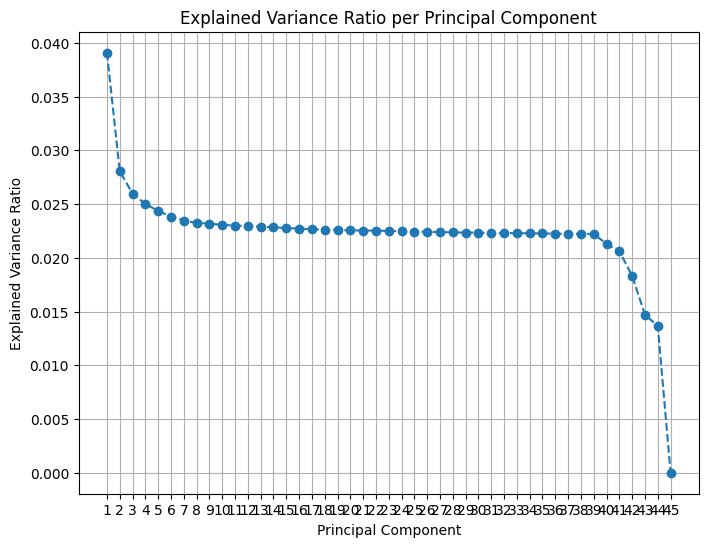

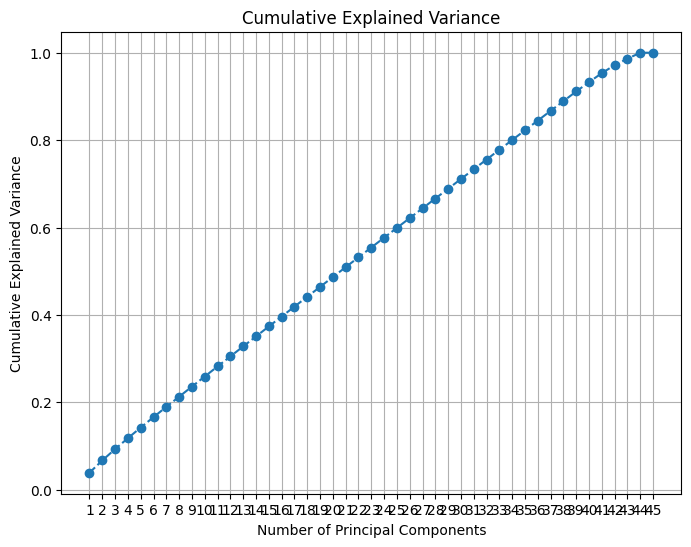

In [84]:
# prompt: identify using chart which PCA components are useful in X_pca

# Plot the explained variance ratio
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio per Principal Component')
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.grid(True)
plt.show()

# Plot the cumulative explained variance
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.grid(True)
plt.show()


ss - This model is not good. Dropping all manufacturers

Number of components explaining 95% of variance: 5
                   PC1       PC2       PC3       PC4       PC5
year          0.702758  0.195811 -0.273391  0.366667  0.508532
fuel          0.541350 -0.236452  0.628608 -0.435501  0.257339
odometer     -0.575633 -0.366894  0.460633  0.507429  0.253714
title_status -0.101155  0.864252  0.480417  0.099409 -0.046430
transmission  0.708235 -0.188324  0.233796  0.395673 -0.501720


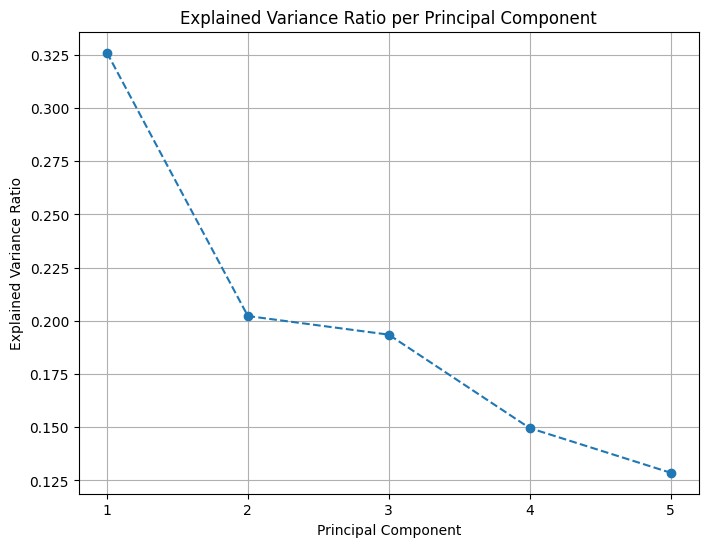

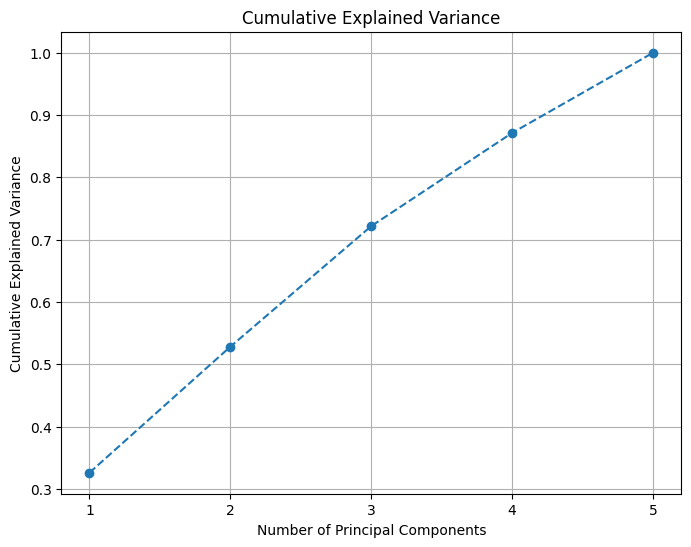

In [85]:
# prompt: drop all manufacturer columns and rerun PCA

# Drop manufacturer columns
manufacturer_cols = [col for col in vehicles_2000.columns if 'manufacturer' in col]
vehicles_2000_dropped = vehicles_2000.drop(columns=manufacturer_cols)

# Normalize the features (X) using StandardScaler
X = vehicles_2000_dropped.drop('price', axis=1)
y = vehicles_2000_dropped['price']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

# Cumulative explained variance
cumulative_variance = np.cumsum(explained_variance_ratio)

# Find the number of components that explain a significant portion of the variance (e.g., 95%)
n_components = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Number of components explaining 95% of variance: {n_components}")

# Apply PCA with the selected number of components
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

# Get the loadings (coefficients) of the principal components
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

# Create a DataFrame of loadings
loadings_df = pd.DataFrame(loadings, columns=[f'PC{i+1}' for i in range(n_components)], index=X.columns)
print(loadings_df)

# Plot the explained variance ratio
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio per Principal Component')
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.grid(True)
plt.show()

# Plot the cumulative explained variance
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.grid(True)
plt.show()


ss run polynomial features regression using all five components

In [86]:
# prompt: un polynomial features regression on X_scaled and y, print coefficients with column names, print mean squared error

from sklearn.preprocessing import PolynomialFeatures

# Assuming X_scaled and y are already defined from the previous code

# Create polynomial features
poly = PolynomialFeatures(degree=2)  # Example: degree 2 polynomial features
X_poly = poly.fit_transform(X_scaled)

# Fit linear regression to the polynomial features
poly_model = LinearRegression()
poly_model.fit(X_poly, y)

# Get feature names after polynomial transformation
poly_feature_names = poly.get_feature_names_out(X.columns)

# Print coefficients with column names
coefficients_poly = pd.DataFrame({'Feature': poly_feature_names, 'Coefficient': poly_model.coef_})
print(coefficients_poly)

# Make predictions on the polynomial features
y_pred_poly = poly_model.predict(X_poly)

# Calculate and print the mean squared error
mse_poly = mean_squared_error(y, y_pred_poly)
print(f"Mean Squared Error (MSE) with Polynomial Features: {mse_poly}")


                      Feature   Coefficient
0                           1      0.000000
1                        year -18620.949131
2                        fuel  19945.977888
3                    odometer -10007.785904
4                title_status -13287.260742
5                transmission  18617.297571
6                      year^2  62334.014995
7                   year fuel -42806.452210
8               year odometer   8236.962851
9           year title_status  11979.216288
10          year transmission  11010.714671
11                     fuel^2   6190.025200
12              fuel odometer  -6049.540935
13          fuel title_status  -4502.631569
14          fuel transmission   5263.278617
15                 odometer^2    217.167047
16      odometer title_status    826.073681
17      odometer transmission   5701.016806
18             title_status^2   1336.003553
19  title_status transmission  -1735.140803
20             transmission^2 -16560.140317
Mean Squared Error (MSE) with Po

ss -Train and test the model

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

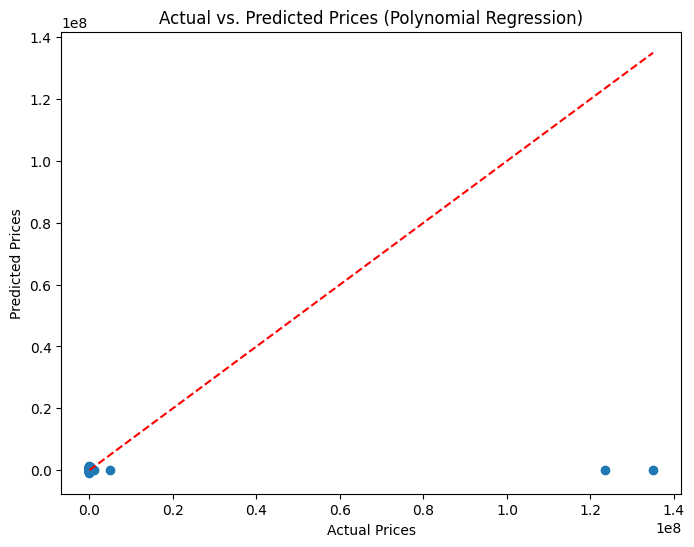

In [87]:
# prompt: train, test and plot predicted vs test data for poly_model

from sklearn.model_selection import train_test_split
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

# Train the model on the training data
poly_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = poly_model.predict(X_test)

# Plot predicted vs. test data
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs. Predicted Prices (Polynomial Regression)")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')  # Add a diagonal line
plt.show()


In [88]:
# prompt: use cross validation to find which parameters are optimal

from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'poly__degree': [1, 2, 3, 4],  # Example degrees for polynomial features
    # Add other parameters to tune here, e.g., for regularization or other model settings
}

# Create the polynomial features object
poly = PolynomialFeatures()

# Create the linear regression model
poly_model = LinearRegression()

# Create a pipeline
from sklearn.pipeline import Pipeline
pipeline = Pipeline([
    ('poly', poly),
    ('model', poly_model)
])


# Create the GridSearchCV object
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error') # 5-fold cross-validation

# Fit the grid search to the data
grid_search.fit(X_scaled, y)

# Print the best parameters and best score
print("Best parameters:", grid_search.best_params_)
print("Best score (negative MSE):", grid_search.best_score_)

# Get the best model from the grid search
best_model = grid_search.best_estimator_

# Use the best model for predictions or further analysis


Best parameters: {'poly__degree': 1}
Best score (negative MSE): -88600931848053.27


As best parameter is one degree . Running simple multiple regression.

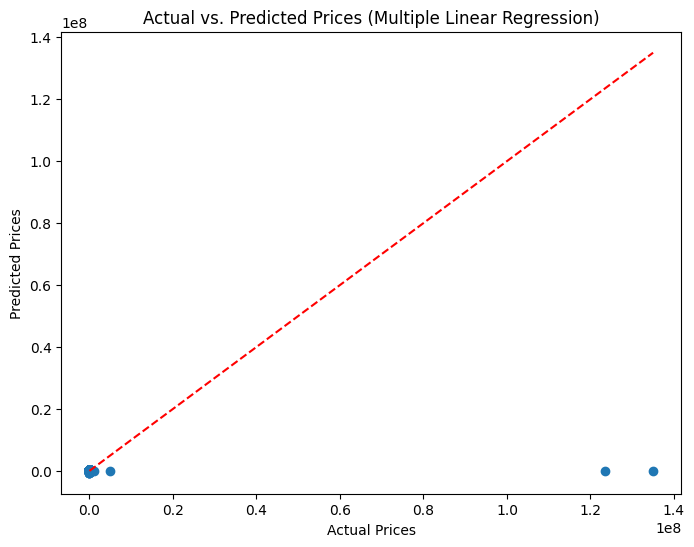

In [89]:
# prompt: Run simple multiple regression, train and tst  on X_scale, plot predicted vs. actual value

# Assuming X_scaled and y are already defined from the previous code
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Initialize and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Plot predicted vs. actual values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs. Predicted Prices (Multiple Linear Regression)")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.show()


Show coefficenets with values of simple multiple linear regression and show mse

In [90]:
# prompt: Show coefficenets with values of simple multiple linear regression and show mse for model

# Assuming X_scaled and y are already defined from the previous code
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Initialize and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Print coefficients with column names
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print(coefficients)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate and print the mean squared error
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE) on test data: {mse}")


        Feature   Coefficient
0          year -71416.437797
1          fuel  14273.726154
2      odometer  -8634.682107
3  title_status  -7920.735377
4  transmission   6296.646675
Mean Squared Error (MSE) on test data: 445271618603.9429


### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

Showing histogram of non label encoded data

In [91]:
Backup_vehicle_2000 = vehicles[vehicles['year']>=2000]

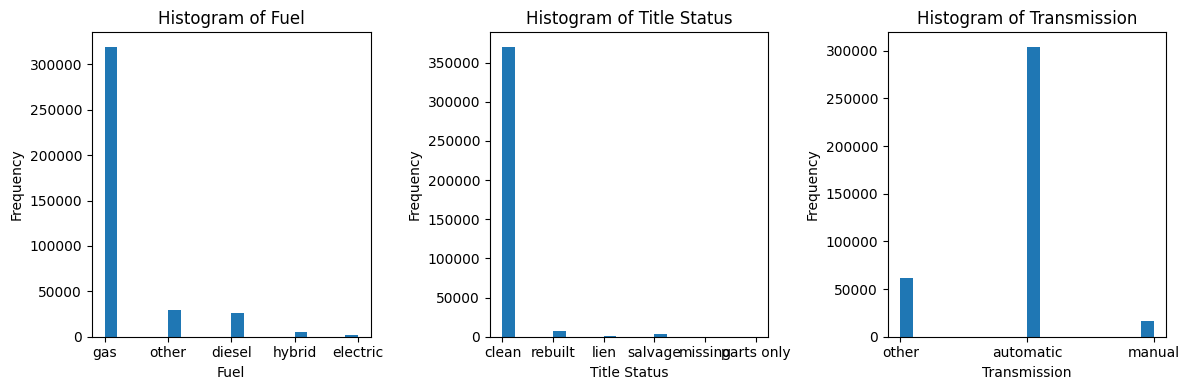

In [92]:
# prompt: show histogram of fuel , title_status , and transmission  values of Backup_vehicle_2000

Backup_vehicle_2000= vehicles[vehicles['year']>=2000]
import matplotlib.pyplot as plt

# Assuming 'vehicles' DataFrame is already loaded and 'Backup_vehicle_2000' is created as shown in the provided code.
# Assuming 'Backup_vehicle_2000' DataFrame exists and contains the necessary columns: 'fuel', 'title_status', and 'transmission'.

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(Backup_vehicle_2000['fuel'], bins=20)
plt.xlabel('Fuel')
plt.ylabel('Frequency')
plt.title('Histogram of Fuel')

plt.subplot(1, 3, 2)
plt.hist(Backup_vehicle_2000['title_status'], bins=20)
plt.xlabel('Title Status')
plt.ylabel('Frequency')
plt.title('Histogram of Title Status')


plt.subplot(1, 3, 3)
plt.hist(Backup_vehicle_2000['transmission'], bins=20)
plt.xlabel('Transmission')
plt.ylabel('Frequency')
plt.title('Histogram of Transmission')

plt.tight_layout()
plt.show()


showing histogram of vehicles state along with their percentage
 with year greater than or equal to 2000

<ipython-input-93-96d6630a29d5>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_vehicles['state'] = temp_vehicles['state'].astype(str)


Text(0.5, 1.0, 'Histogram of Fuel')

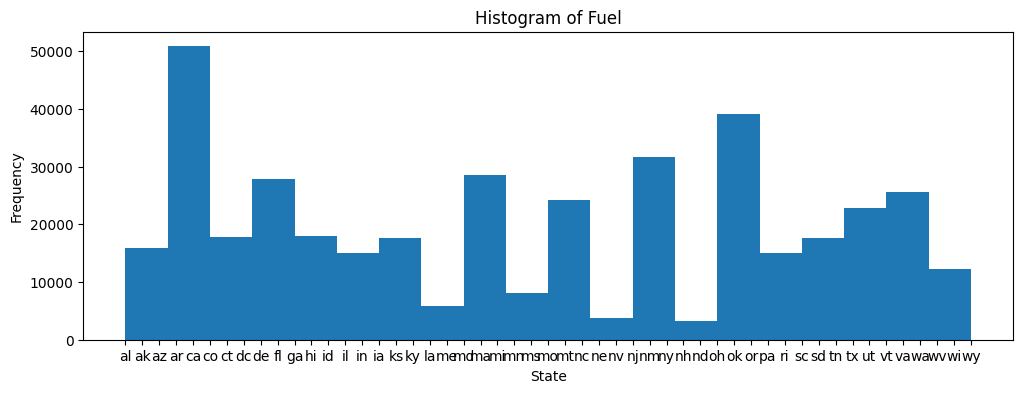

In [93]:
vehicles_state = pd.read_csv('data/vehicles.csv')
temp_vehicles = vehicles_state[vehicles_state['year']>=2000]

# Convert 'state' column to string type
temp_vehicles['state'] = temp_vehicles['state'].astype(str)

plt.figure(figsize=(12, 4))

#plt.subplot(1, 3, 1)
plt.hist(temp_vehicles['state'], bins=20)
plt.xlabel('State')
plt.ylabel('Frequency')
plt.title('Histogram of Fuel')


Running simple linear regression with only year and odometer with price as target from X_scaled

Mean Squared Error (MSE) on test data: 444921786402.82336


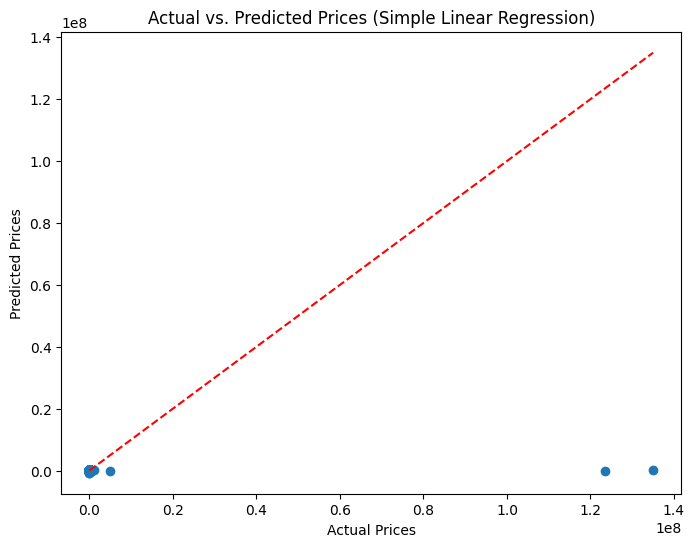

,Feature,Coefficient
0,year,-67882.217753
1,odometer,-9866.396594


In [94]:
# prompt: Run simple linear multiple regression with only year and odometer with price as target from X_scaled. Train and Test it. Show MSE and plot predicted vs actual test Y. Show coefficients

# Assuming X_scaled and y are already defined from the previous code
# Select only 'year' and 'odometer' columns from X_scaled
X_scaled_subset = X_scaled[:, [X.columns.get_loc('year'), X.columns.get_loc('odometer')]]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled_subset, y, test_size=0.2, random_state=42)

# Initialize and train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate and print the mean squared error
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE) on test data: {mse}")

# Plot predicted vs. actual values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs. Predicted Prices (Simple Linear Regression)")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.show()

# Print coefficients with column names
coefficients = pd.DataFrame({'Feature': ['year', 'odometer'], 'Coefficient': model.coef_})
coefficients


Final Conclusion -

Prices are inversely dependent on the year car was made. Newer the car more expensive it will be.

Prices are inversely dependent on odeometer value . less miles on  the car more expensive it will be.

Impact of year is much higher than impact of odometer.

majority of cars will use gas fuel, will have clean title and automatic transmission.

Most old cars sold since year 2000 are from California.
